# Customer Churn Analysis and Prediction

**Author:** Kinga Jaszewska  
**Tools:** Python, pandas, seaborn, scikit-learn  
**Project type:** Exploratory data analysis and binary classification

This project examines customer behavior in a telecommunications dataset and builds an interpretable model that flags customers at risk of leaving. The focus is not only predictive performance, but also the business trade-off between finding more churners and contacting customers who would have stayed.

## 1. Business objective

Customer churn reduces recurring revenue and increases the need for costly acquisition. The analysis answers three questions:

1. Which behaviors are associated with higher churn?
2. Can a simple, explainable model identify customers at risk?
3. How does class imbalance change the way model quality should be assessed?

Because only about 15% of customers churn, accuracy alone is not a sufficient metric. Recall is especially important when the business cost of missing a churner is higher than the cost of contacting a customer who would have stayed.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#2563EB"
DARK_BLUE = "#1E3A8A"
LIGHT_BLUE = "#93C5FD"
ORANGE = "#F97316"

In [2]:
# Find the project root whether the notebook is run from the repository
# root or from the notebooks directory.
candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (path for path in candidates if (path / "data" / "Telco.csv").exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Place Telco.csv in the data/ directory before running the notebook."
    )

DATA_PATH = PROJECT_ROOT / "data" / "Telco.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.drop(columns=["Phone"]).head()

,Account_Length,Vmail_Message,Day_Mins,Eve_Mins,Night_Mins,Intl_Mins,CustServ_Calls,Churn,Intl_Plan,Vmail_Plan,Day_Calls,Day_Charge,Eve_Calls,Eve_Charge,Night_Calls,Night_Charge,Intl_Calls,Intl_Charge,State,Area_Code
0,128,25,265.1,197.4,244.7,10.0,1,no,no,yes,110,45.07,99,16.78,91,11.01,3,2.70,KS,415
1,107,26,161.6,195.5,254.4,13.7,1,no,no,yes,123,27.47,103,16.62,103,11.45,3,3.70,OH,415
2,137,0,243.4,121.2,162.6,12.2,0,no,no,no,114,41.38,110,10.30,104,7.32,5,3.29,NJ,415
3,84,0,299.4,61.9,196.9,6.6,2,no,yes,no,71,50.90,88,5.26,89,8.86,7,1.78,OH,408
4,75,0,166.7,148.3,186.9,10.1,3,no,yes,no,113,28.34,122,12.61,121,8.41,3,2.73,OK,415


## 2. Data overview and quality checks

In [3]:
overview = pd.DataFrame(
    {
        "rows": [df.shape[0]],
        "columns": [df.shape[1]],
        "missing_values": [int(df.isna().sum().sum())],
        "duplicate_rows": [int(df.duplicated().sum())],
    }
)
overview

,rows,columns,missing_values,duplicate_rows
0,3333,21,0,0


In [4]:
target_counts = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customers")
)
target_counts["Share"] = target_counts["Customers"] / len(df)
target_counts

,Churn,Customers,Share
0,no,2850,0.855086
1,yes,483,0.144914


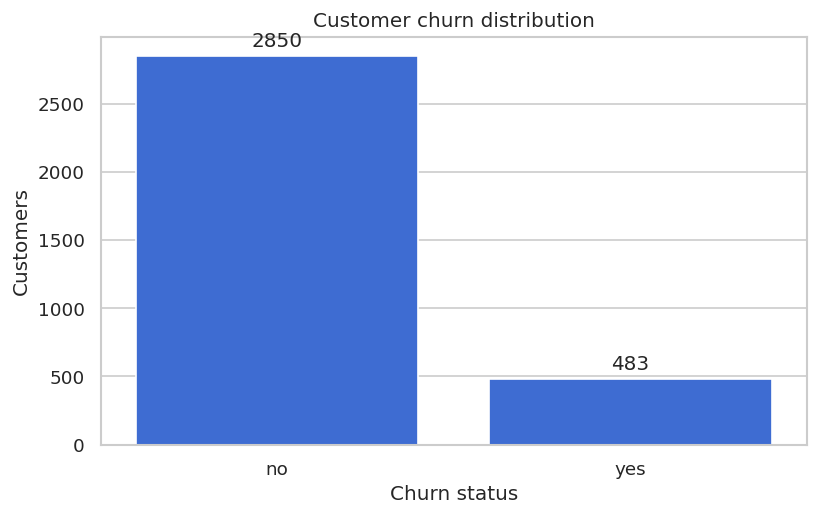

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=target_counts, x="Churn", y="Customers", color=BLUE, ax=ax)
ax.set(title="Customer churn distribution", xlabel="Churn status", ylabel="Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "churn_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The dataset contains **3,333 customers** and no missing or duplicated rows. Only **14.5%** of customers churned. A model that predicts “no churn” for everyone would therefore reach 85.5% accuracy while detecting no churners. This is why the analysis also uses recall, precision, F1, ROC-AUC and PR-AUC.

## 3. Exploratory analysis

In [6]:
analysis_df = df.copy()
analysis_df["Churn_Flag"] = analysis_df["Churn"].map({"no": 0, "yes": 1})
analysis_df["Service_Call_Group"] = pd.cut(
    analysis_df["CustServ_Calls"],
    bins=[-1, 1, 3, np.inf],
    labels=["0-1", "2-3", "4+"],
)
analysis_df["Day_Minutes_Quartile"] = pd.qcut(
    analysis_df["Day_Mins"],
    q=4,
    labels=["Q1: lowest", "Q2", "Q3", "Q4: highest"],
)

churn_by_international_plan = (
    analysis_df.groupby("Intl_Plan")["Churn_Flag"].mean().mul(100).round(1)
)
churn_by_service_calls = (
    analysis_df.groupby("Service_Call_Group", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .round(1)
)
churn_by_day_minutes = (
    analysis_df.groupby("Day_Minutes_Quartile", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .round(1)
)

pd.DataFrame(
    {
        "International plan": churn_by_international_plan,
    }
)

,International plan
Intl_Plan,
no,11.5
yes,42.4


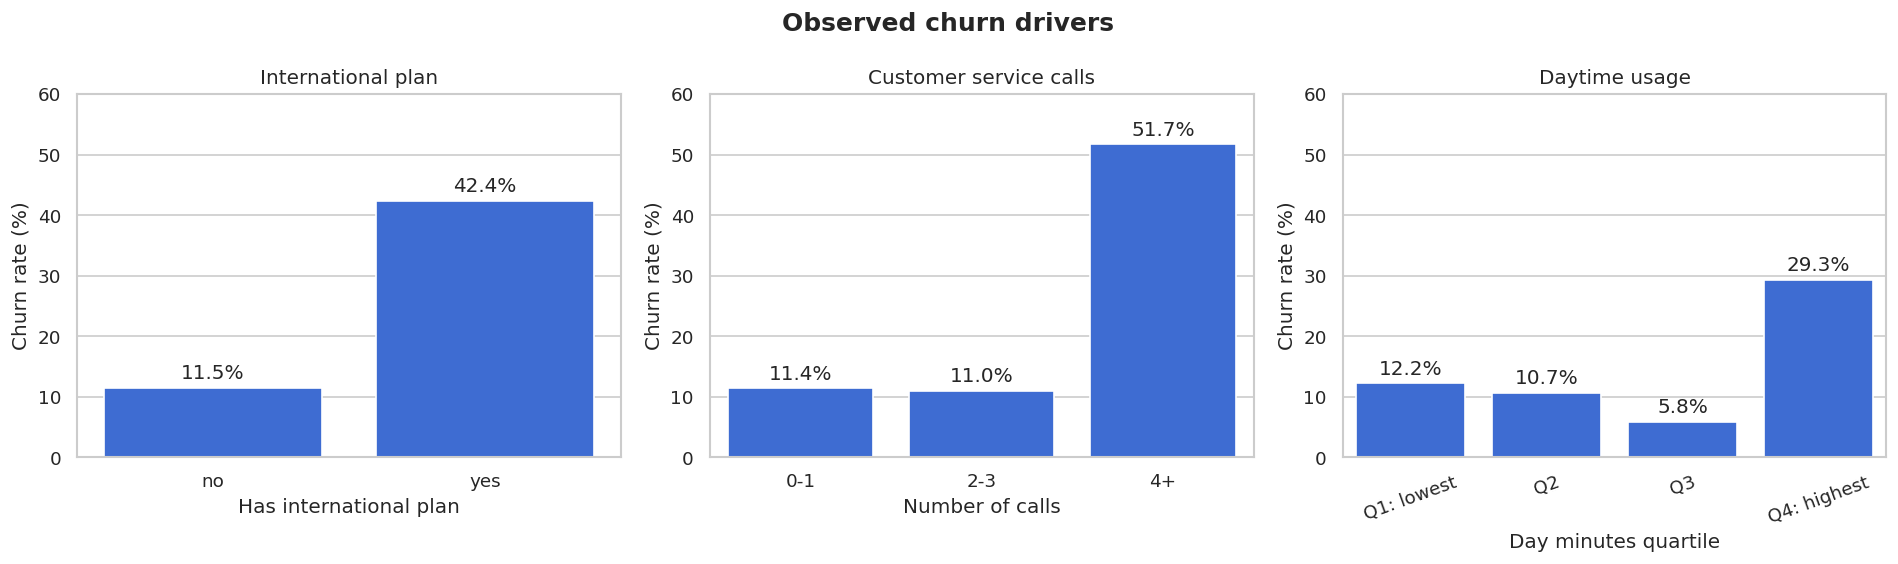

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.barplot(
    x=churn_by_international_plan.index,
    y=churn_by_international_plan.values,
    color=BLUE,
    ax=axes[0],
)
axes[0].set(title="International plan", xlabel="Has international plan", ylabel="Churn rate (%)")

sns.barplot(
    x=churn_by_service_calls.index,
    y=churn_by_service_calls.values,
    color=BLUE,
    ax=axes[1],
)
axes[1].set(title="Customer service calls", xlabel="Number of calls", ylabel="Churn rate (%)")

sns.barplot(
    x=churn_by_day_minutes.index,
    y=churn_by_day_minutes.values,
    color=BLUE,
    ax=axes[2],
)
axes[2].set(title="Daytime usage", xlabel="Day minutes quartile", ylabel="Churn rate (%)")
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.set_ylim(0, 60)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

fig.suptitle("Observed churn drivers", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "churn_drivers.png", dpi=160, bbox_inches="tight")
plt.show()

### Key findings

- Customers with an international plan churned at **42.4%**, compared with **11.5%** among customers without one.
- Customers who contacted customer service at least four times churned at **51.7%**. The rate was close to 11% for customers with three or fewer calls.
- Customers in the highest quartile of daytime usage churned at **29.3%**, much more often than the remaining groups.

These are associations, not proof of causation. They nevertheless identify useful segments for further investigation and targeted retention actions.

## 4. Data preparation

The following choices improve interpretability and reduce leakage or unnecessary complexity:

- `Phone` is an identifier and is not used for prediction.
- `State` and `Area_Code` are excluded because small geographic groups may overfit and are not directly actionable.
- Charge columns are excluded because they are almost deterministic transformations of minute columns.
- `Vmail_Message` is excluded because it strongly overlaps with information in `Vmail_Plan`.
- The split is stratified so both sets keep a similar churn rate.
- Preprocessing is fitted only on training data through a scikit-learn pipeline.

In [8]:
target = df["Churn"].map({"no": 0, "yes": 1})

excluded_features = [
    "Churn",
    "Phone",
    "State",
    "Area_Code",
    "Day_Charge",
    "Eve_Charge",
    "Night_Charge",
    "Intl_Charge",
    "Vmail_Message",
]
features = df.drop(columns=excluded_features)

categorical_features = features.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = features.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.30,
    random_state=42,
    stratify=target,
)

pd.DataFrame(
    {
        "set": ["training", "test"],
        "rows": [len(X_train), len(X_test)],
        "churn_rate": [y_train.mean(), y_test.mean()],
    }
)

,set,rows,churn_rate
0,training,2333,0.144878
1,test,1000,0.145000


In [9]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

## 5. Model comparison

Three approaches are compared with stratified five-fold cross-validation:

1. A dummy classifier that always predicts the majority class.
2. Standard logistic regression.
3. Logistic regression with balanced class weights, which gives more importance to churn cases.

In [10]:
models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=2000, random_state=42),
    "Balanced logistic regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparison_rows = []
for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    comparison_rows.append(
        {
            "Model": model_name,
            **{
                metric: scores[f"test_{metric}"].mean()
                for metric in scoring
            },
        }
    )

comparison = pd.DataFrame(comparison_rows).set_index("Model")
comparison.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Model,,,,,,
Dummy baseline,0.855,0.00,0.000,0.000,0.500,0.145
Logistic regression,0.856,0.52,0.175,0.260,0.814,0.450
Balanced logistic regression,0.769,0.36,0.763,0.489,0.816,0.437


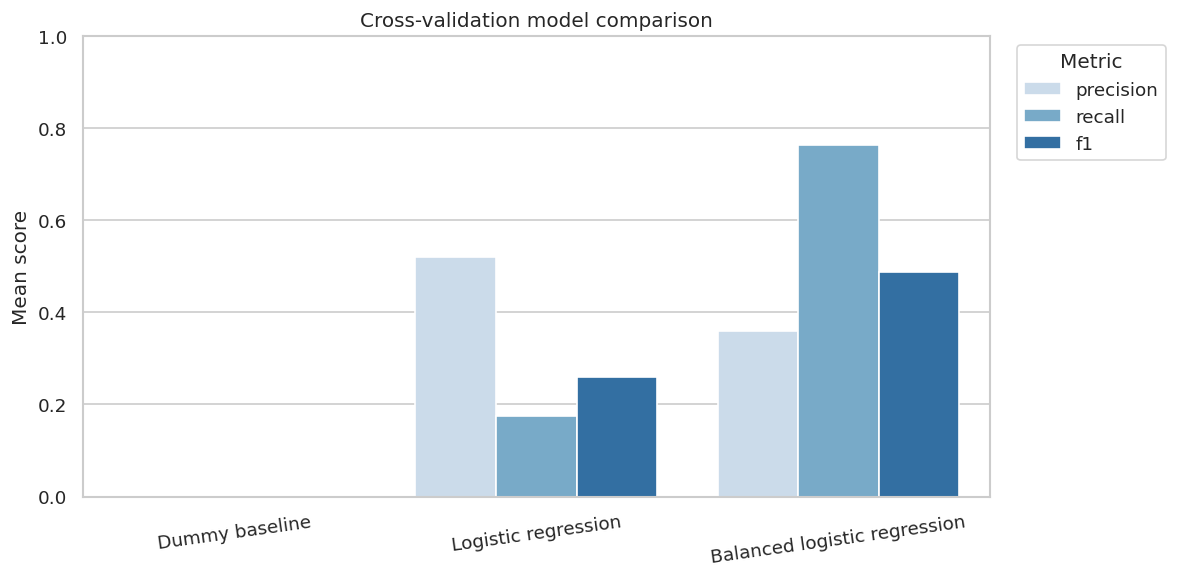

In [11]:
plot_data = comparison[["precision", "recall", "f1"]].reset_index().melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_data, x="Model", y="Score", hue="Metric", palette="Blues", ax=ax)
ax.set(title="Cross-validation model comparison", xlabel="", ylabel="Mean score", ylim=(0, 1))
ax.tick_params(axis="x", rotation=8)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The standard model retains high accuracy but misses most churners. The balanced model sacrifices some accuracy and precision to achieve much higher recall and F1. This is the preferred trade-off when the purpose is to create a useful shortlist for retention outreach.

## 6. Final model evaluation

In [12]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

final_model.fit(X_train, y_train)
predictions = final_model.predict(X_test)
probabilities = final_model.predict_proba(X_test)[:, 1]

test_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
    },
    name="Test score",
)
test_metrics.to_frame().round(3)

,Test score
Accuracy,0.759
Precision,0.344
Recall,0.731
F1,0.468
ROC-AUC,0.817
PR-AUC,0.459


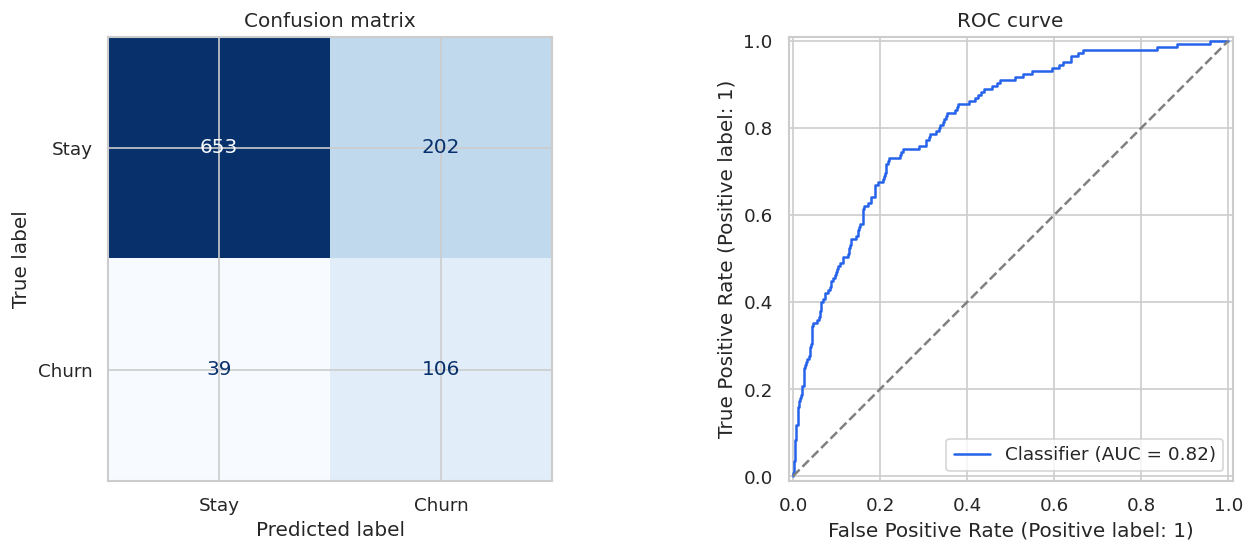

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Stay", "Churn"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test, probabilities, color=BLUE, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC curve")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "final_model_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()

In [14]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

business_summary = pd.Series(
    {
        "Actual churners in test set": int(tp + fn),
        "Churners detected": int(tp),
        "Churners missed": int(fn),
        "Customers flagged for outreach": int(tp + fp),
        "False alarms": int(fp),
    }
)
business_summary.to_frame("Customers")

,Customers
Actual churners in test set,145
Churners detected,106
Churners missed,39
Customers flagged for outreach,308
False alarms,202


On the held-out test set, the balanced model detected **106 of 145 churners** (73.1% recall). It flagged 308 customers for outreach, including 202 customers who did not churn. Whether this is profitable depends on the cost of a retention offer and the expected value of keeping a customer. The model should therefore support prioritization, not make fully automated decisions.

## 7. Interpreting model coefficients

In [15]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = final_model.named_steps["model"].coef_[0]

coefficient_table = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
    .assign(
        Feature=lambda frame: (
            frame["Feature"]
            .str.replace("numeric__", "", regex=False)
            .str.replace("categorical__", "", regex=False)
        )
    )
    .sort_values("Coefficient")
)
coefficient_table

,Feature,Coefficient
11,Vmail_Plan_yes,-0.768158
9,Intl_Calls,-0.295075
8,Night_Calls,-0.020539
6,Day_Calls,0.036931
0,Account_Length,0.071943
7,Eve_Calls,0.082979
3,Night_Mins,0.127633
4,Intl_Mins,0.220555
2,Eve_Mins,0.322859
1,Day_Mins,0.629172


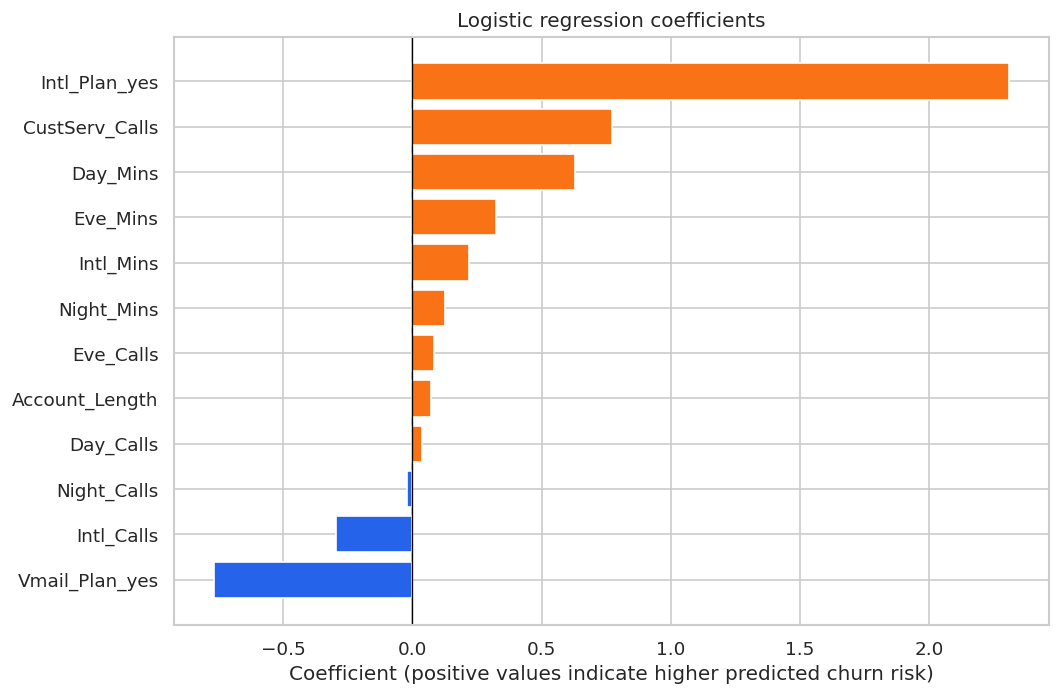

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = [ORANGE if value > 0 else BLUE for value in coefficient_table["Coefficient"]]
ax.barh(coefficient_table["Feature"], coefficient_table["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Logistic regression coefficients",
    xlabel="Coefficient (positive values indicate higher predicted churn risk)",
    ylabel="",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

The strongest positive associations in the model are having an international plan, making more customer service calls and using more daytime minutes. Having a voicemail plan is associated with lower predicted churn risk. Coefficients describe patterns in this dataset and should not be interpreted as causal effects.

## 8. Recommendations and limitations

### Recommendations

1. Review the pricing and customer experience of the international plan.
2. Create an escalation path after the third customer service contact.
3. Investigate whether high daytime usage is linked to pricing dissatisfaction.
4. Use predicted probabilities to prioritize outreach according to campaign capacity and offer cost.
5. Validate the model on recent, real operational data before deployment.

### Limitations

- The supplied dataset does not contain collection dates or detailed source metadata.
- Model results describe associations and do not measure the causal effect of a retention action.
- The probability threshold was not optimized against real campaign costs.
- Performance may change for new customer populations or newer pricing structures.